# Code Lab 4. Keras Optimization 

Для выполнения этого задания нужно будет дописать код в этом ноутбуке  

В этом упражнении Вам предстоит:

- найти лучшие гиперпараметры **learning rate и regularization** 
- **визуализировать** матрицу оптимальных весов.

In [1]:
import time
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'

# Загрузка датасета CIFAR-10 и предварительная подготовка

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Проверим размер входных и выходных векторов.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print()

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)



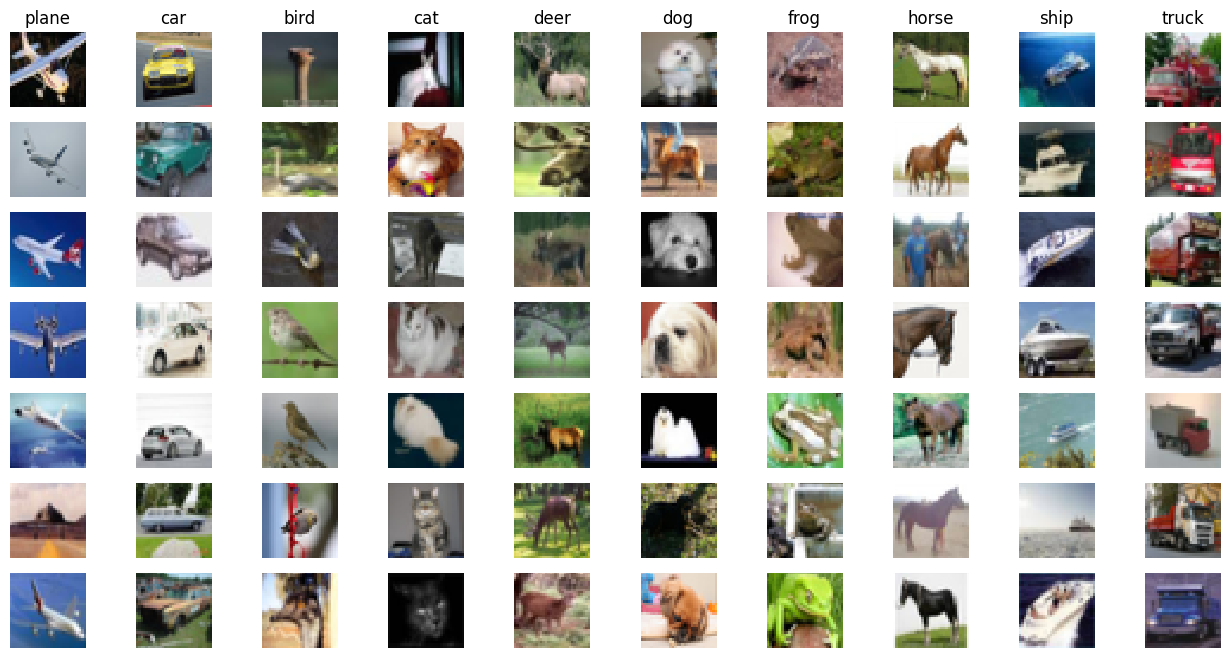

In [3]:
# Перед началом работы полезно посмотреть на данные.
# Отобразим пример из каждого класса.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Для удобства преобразуем двумерные изображения в одномерные вектора fp64
X_train = np.reshape(X_train, (X_train.shape[0], -1)).astype(np.float64)
X_test = np.reshape(X_test, (X_test.shape[0], -1)).astype(np.float64)
y_train = y_train.flatten()
y_test = y_test.flatten()
# Проверим размер полученных данных
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('Training label shape: ', y_train.shape)
print('Test label shape: ', y_test.shape)

Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)
Training label shape:  (50000,)
Test label shape:  (10000,)


[130.71074 136.05614 132.5538  130.14036 135.44238 131.85358 131.05044
 136.24616 132.58144 131.56886]


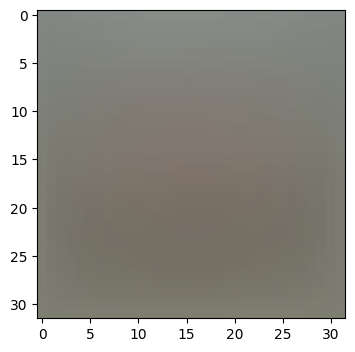

In [5]:
# Нормализуем значения яркости пикселей 
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 

# визуализируем среднюю яркость
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

In [6]:
# Вычтем средние значения яркости
X_train -= mean_image
X_test -= mean_image

# Добавим к вектору исходных данных фиктивный признак с постоянным значением 1.
# Этот трюк позволит избежать лишних вычислений: x @ W + b  => x' @ W'
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_test.shape)

(50000, 3073) (10000, 3073)


# Стохастический градиентный спуск

In [7]:
# Используем линейную модель keras
softmax_cls = tf.keras.Sequential([
    tf.keras.layers.Dense(num_classes, activation='softmax', input_shape=(3073,))
]) 

C:\Users\alexm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
%time
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-4, momentum=0.9)
softmax_cls.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
loss_hist = softmax_cls.fit(X_train[:3000], y_train[:3000], epochs=10, batch_size=200)


CPU times: total: 0 ns
Wall time: 5.48 μs
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2093 - loss: 84.3921   
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2990 - loss: 53.5104 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3373 - loss: 45.8539 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3543 - loss: 39.8233 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3890 - loss: 35.2359 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4163 - loss: 32.0722 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4157 - loss: 35.8140 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4137 - loss: 33.5798 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4417 - loss: 34.6526 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4633 - loss: 29.1631 


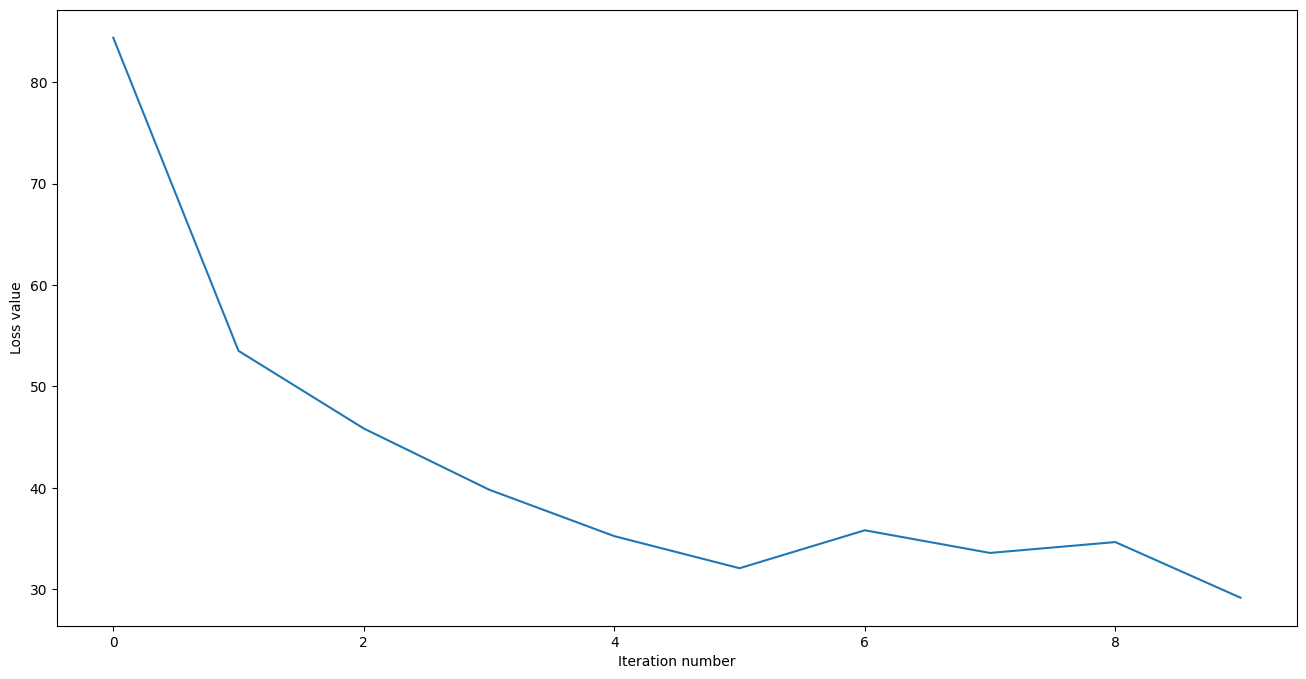

In [9]:
# Построим график зависимости loss от количества итераций
plt.plot(loss_hist.history['loss'])
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [10]:
# оцените точность предсказания на выборках train и val
y_train_pred = np.argmax(softmax_cls.predict(X_train), axis=1)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred) ))
y_test_pred = np.argmax(softmax_cls.predict(X_test), axis=1)
print('validation accuracy: %f' % (np.mean(y_test == y_test_pred) ))

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step
training accuracy: 0.274080
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step
validation accuracy: 0.257700


# Поиск лучших гиперпараметров

In [11]:
# Используйте валидационную выборку для выбора лучших гиперпараметров 
# (learning rate and regularization strength)
# Добейтесь точности не меньше 0.38 на выборке test.
# Используйте словарь results в котором 
# ключи - кортеж  (learning_rate, regularization_strength)
# значения - (training_accuracy, validation_accuracy)
# Точность вычисляется как отношение числа верно предсказанных классов 
# к объему выборки
results = {}
best_val = -1   
best_softmax = None # Лучший экземпляр Softmax classifier 

################################################################################
# TODO:                                                                        #
# Напишите код, позволяющий найти лучшее значение гиперпараметров на val       #
# выборке. Для каждой комбинации гиперпараметров обучите классификатор         #
# на train выборке, вычислите точность на выборках train, val и сохраните      #
# результат в словарь results. Лучшее значение точности сохраните в best_val   #
# лучший классификатор - в best_softmax                                        #
#                                                                              #
################################################################################

# Пример списка допустимых значений. Можете изменить на свое усмотрение.
#learning_rates = [1e-7, 5e-5]
#regularization_strengths = [1e-1, 1, 10]

learning_rates = [1e-7, 5e-7, 1e-6]
regularization_strengths = [1e4, 2.5e4]

# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        # 1. Создаем модель с L2 регуляризацией
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(10, activation='softmax', 
                                  input_shape=(3073,),
                                  kernel_regularizer=tf.keras.regularizers.l2(reg))
        ])
        
        # 2. Компилируем
        model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        
        # 3. Обучаем (используем validation_split вместо ручного нарезания)
        model.fit(X_train, y_train, epochs=10, batch_size=200, 
                  validation_split=0.1, verbose=0)
        
        # 4. Получаем точность из истории обучения или через evaluate
        train_acc = model.evaluate(X_train, y_train, verbose=0)[1]
        val_acc = model.evaluate(X_train[-1000:], y_train[-1000:], verbose=0)[1]
        
        results[(lr, reg)] = (train_acc, val_acc)
        
        if val_acc > best_val:
            best_val = val_acc
            # Сохраняем веса, так как объект модели в цикле перезаписывается
            best_softmax_weights = model.get_weights()

best_softmax = tf.keras.models.clone_model(model)
best_softmax.set_weights(best_softmax_weights)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
# Вывод результатов.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.299520 val accuracy: 0.300000
lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.328720 val accuracy: 0.344000
lr 5.000000e-07 reg 1.000000e+04 train accuracy: 0.358880 val accuracy: 0.364000
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.324000 val accuracy: 0.336000
lr 1.000000e-06 reg 1.000000e+04 train accuracy: 0.348420 val accuracy: 0.358000
lr 1.000000e-06 reg 2.500000e+04 train accuracy: 0.321780 val accuracy: 0.340000
best validation accuracy achieved during cross-validation: 0.364000


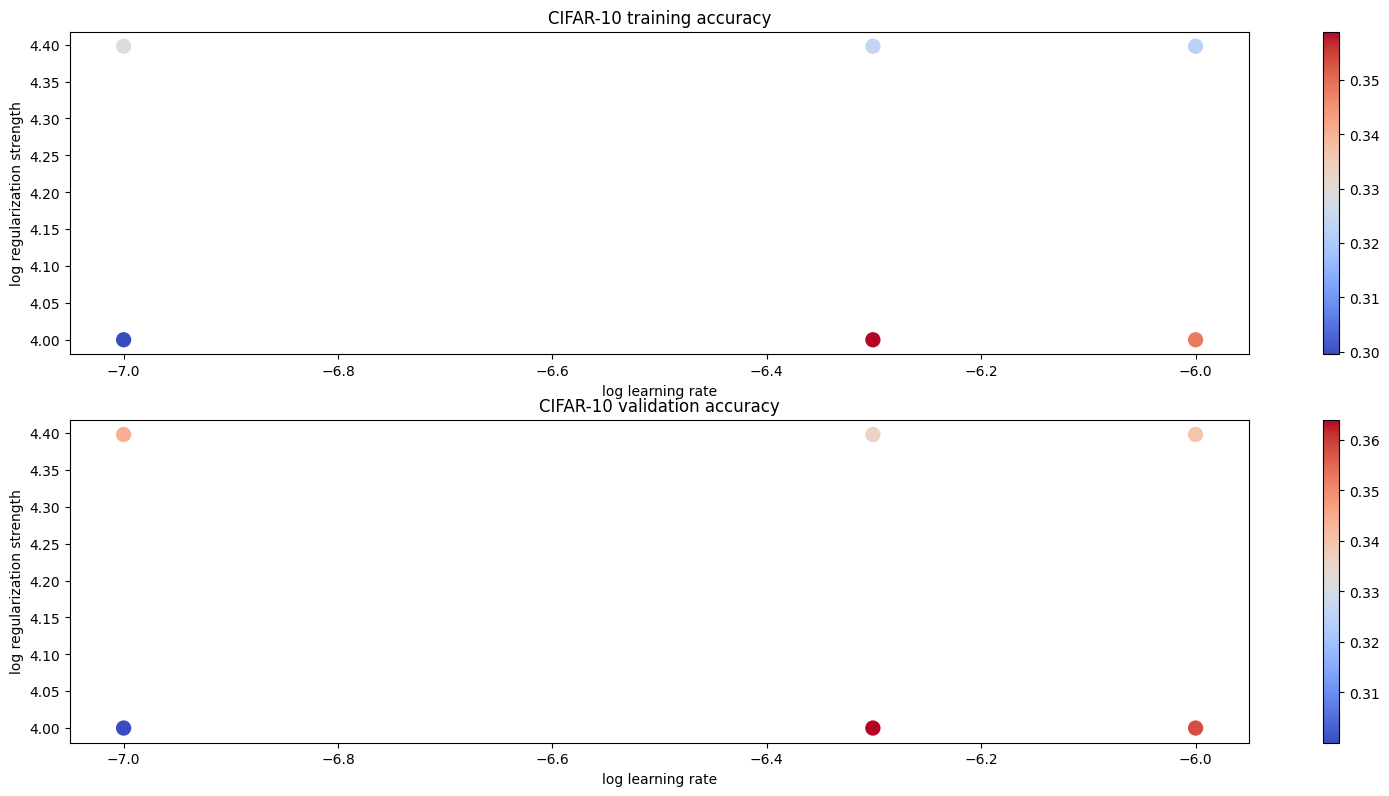

In [12]:
# Визуализируем результаты кросс-валидации
import math

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# график accuracy на обучении
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# график accuracy на валидации
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

# Точность на test выборке


In [13]:
y_test_pred = np.argmax(best_softmax.predict(X_test), axis=1)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step
softmax on raw pixels final test set accuracy: 0.357900


In [14]:
best_softmax.save('softmax_weights.keras')

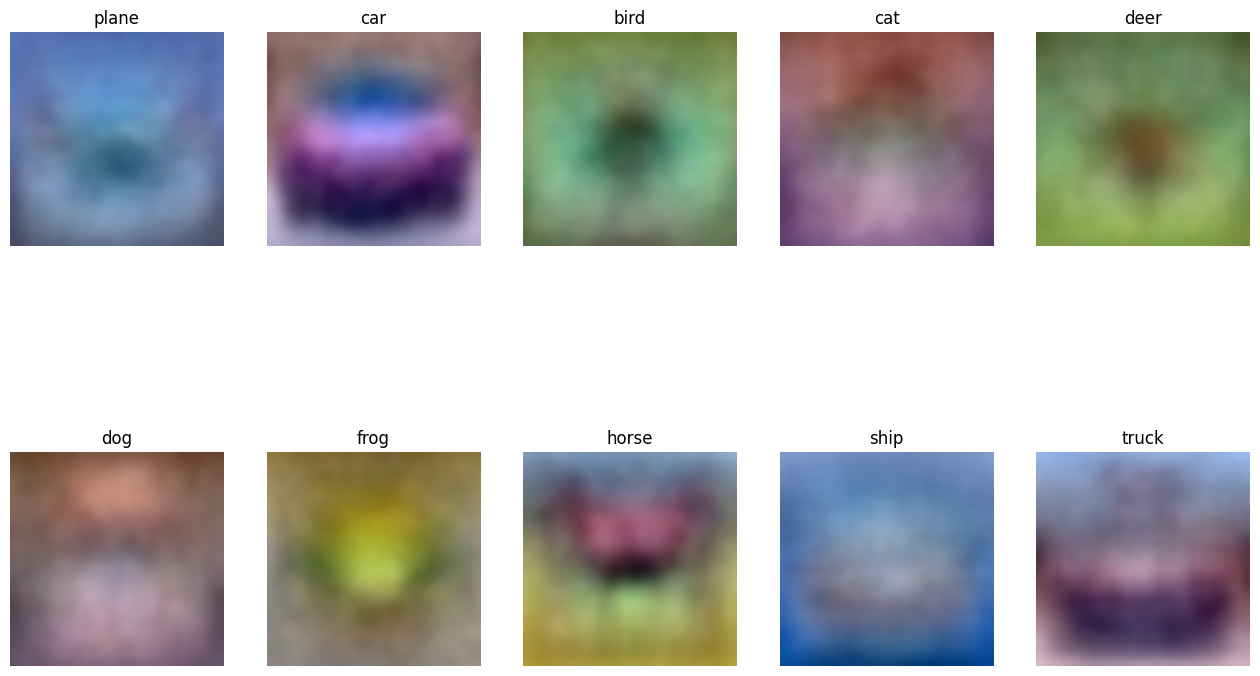

In [15]:
# Визуализируем веса W для каждого класса
w = best_softmax.get_weights()[0][:-1,:] # отбросим фиктивное измерение bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(16, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Масштабируем веса в значения от 0 до 255 для визуализации
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'), interpolation='quadric')
    plt.axis('off')
    plt.title(classes[i])